# Multiple Stochastic Timestamps and Stochastic Sampling of Red/Blue and Green/Yellow Events Example

This example demonstrates how to generate a real-time/scaled-time stochastic time series with **multiple stochastic events**, analyze the occurrences of these events in specified intervals, and visualize the results. <br>
This example is much like example 2, but introduces multiple distinct event types, instead of only one. In this example, one event generates either red or blue and another event generates either green or yellow. <br>
**Please go through the examples 1 and 2 before this one.** <br>

## Imports

In [1]:
import numpy as np
import logging

from EventStreamGenerator import EventTimestampGenerator, EventSampleSpace, EventStreamGenerator
from analytics import plot_timeline_with_colors, count_number_of_occurrences_in_intervals

## Configure Logging

Logging is configured to show **INFO** level messages and above, with a specific format that includes the timestamp, logger name, log level, and message.To observe internal characteristics of the generator and its components, change the log-level to **DEBUG**.

In [2]:
logger = logging.getLogger(__name__)

logging.basicConfig(
    level=logging.INFO,                            
    format="%(asctime)s %(name)s %(levelname)s: %(message)s",
)

## Configure Inputs

The inputs are configured for this example. Including:
- **max_time**: End boundary of intervals and maximum time the simulation will run
- **intervals**: 1 second intervals [(0, 1), (1, 2), (2, 3)]
- **time_scaling**: This scales the time, if set to 1 it is outputting in real-time, and when set to 100 it runs 100 times faster than real-time.
- **event_handler**: This function is invoked with event details whenever an event is occurring.
- **noise_sds**: Noise standard deviations - the standard deviations of the noises to be added to the samples, which is normally distributed with mean 0.
- **occurrence_noise_sds**: Occurrences Noise Standard Deviations - the standard deviations of the noises to be added to the "number of occurrences" samples, which is normally distributed with mean occurrences[i], for each interval i.
  
For this example, each event type has its own occurrence parameter, where the red/blue events occurs following [1, 2, 3] and the green/yellow occurs following [3, 2, 1]. To recap, the occurrence parameter dictates the number of times the event are to occur in each interval. The parameter [1, 2, 3] means that an event will occur once in the interval (0,1), twice in (1, 2) etc. The parameters are called:
- **occurrences_red_blue** 
- **occurrences_green_yellow**

The events share noise standard deviation and occurrence noise standard deviation. 


In [3]:
max_time = 3
intervals = [(i, i+1) for i in range(max_time)]
time_scaling = 100 # 1 is real-time

# Event Noise Standard Deviation
__noise_sd = .5
noise_sds = [__noise_sd]*max_time

# Occurrence Noise Standard Deviation
__occurrence_noise_sd = 1
occurrence_noise_sds = [__occurrence_noise_sd]*max_time

print("Time intervals:", intervals)
print("Noise Standard Deviations:", noise_sds)
print("Occurrence Noise Standard Deviations:", occurrence_noise_sds)


# Callback function to handle events
def event_handler(event):
    logger.info(f"New event: {event}")
    logger.info("--------")


# NEW/CHANGED INPUTS
occurrences_red_blue = [i+1 for i in range(max_time)]
occurrences_green_yellow = [max_time-i for i in range(max_time)]

print("Occurrences for the red blue event type:", occurrences_red_blue)
print("Occurrences for the green yellow event type:", occurrences_green_yellow)

Time intervals: [(0, 1), (1, 2), (2, 3)]
Noise Standard Deviations: [0.5, 0.5, 0.5]
Occurrence Noise Standard Deviations: [1, 1, 1]
Occurrences for the red blue event type: [1, 2, 3]
Occurrences for the green yellow event type: [3, 2, 1]


## Configure Constraints

Constraints can be used on both event timestamp generator (ETG) and event samples spaces (ESS). When a valid non-empty constraint set is added, the ETG and ESS will enforce that these constraints are met by resampling.

In [4]:
from typing import Any, Callable, Set
# Timestamp Constraints
timestamp_constraints: Set[Callable[[dict, Any], bool]]={
                     # Every timestamp (ts) must be non-negative
                     lambda state, ts: ts > 0, 
                     # Every timestamp (ts) must be greater than the prior expect for the first datapoint
                     lambda state, ts: ts > state["timestamps"][-1] if (len(state["timestamps"])) != 0 else True,
                     # Every timestamp (ts) must be within its own interval
                     lambda state, ts: state["time_intervals"][state["current_interval"]][0] <= ts < state["time_intervals"][state["current_interval"]][1]
                }
# Occurrence Constraints
occurrences_constraints: Set[Callable[[dict, Any], bool]]={
    # The number of occurrences must be non-negative
    lambda state, o: o >= 0
}

## Define Events

In [5]:
# -- Common EventTimestampGenerator For Both Events --
class StochasticETG(EventTimestampGenerator):
    """Class representing the frequency of events over time, defined by occurrences and time intervals"""
    def __init__(self, occurrences, time_intervals, timestamp_constraints, occurrences_constraints, noise_sds, occurrences_sds):
        self.noise_sds = noise_sds
        self.occurrences_sds = occurrences_sds
        super().__init__(occurrences, time_intervals, timestamp_constraints, occurrences_constraints)
    
    def sample_noise(self, i):
        return np.random.normal(loc=0, scale=self.noise_sds[i])
    
    def sample_occurrences(self, occurrences_i, i):
        return int(np.round(np.random.normal(loc=occurrences_i, scale=self.occurrences_sds[i])))

# -- Distinct EventSampleSpace Classes for Each Event Type --
# Red Blue Sample Space
class RedBlueSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
        self.values = ["red", "blue"]
        self.probabilities = [0.5, 0.5]

    def sample(self, t):
        return str(np.random.choice(self.values, p=self.probabilities))
# Green Yellow Sample Space
class GreenYellowSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
        self.values = ["green", "yellow"]
        self.probabilities = [0.5, 0.5]

    def sample(self, t):
        return str(np.random.choice(self.values, p=self.probabilities))
    

# -- Define Events --
# Red Blue Event
etg_red_blue = StochasticETG(occurrences_red_blue, intervals, timestamp_constraints, occurrences_constraints, noise_sds, occurrence_noise_sds) # NOTE: each event MUST have its own ETG instance
ess_red_blue = RedBlueSampleSpace()
event_red_blue = (etg_red_blue, ess_red_blue)

# Green Yellow Event
etg_green_yellow = StochasticETG(occurrences_green_yellow, intervals, timestamp_constraints, occurrences_constraints, noise_sds, occurrence_noise_sds) # NOTE: each event MUST have its own ETG instance
ess_green_yellow = GreenYellowSampleSpace()
event_green_yellow = (etg_green_yellow, ess_green_yellow)

## Run Generator

In [6]:
# Initialize the TimeSeriesGenerator with the ETG and ESS
time_series_generator = EventStreamGenerator([event_red_blue, event_green_yellow], event_handler)
# Run the generator to produce data for "max_time" time with a time-scaling of 100
data = time_series_generator.run(max_time, time_scaling)

# Log results
logger.info(f"Generated data: {data}")

2025-08-11 14:08:11,683 __main__ INFO: New event: (0.6485081308263926, 'blue')
2025-08-11 14:08:11,684 __main__ INFO: --------
2025-08-11 14:08:11,684 __main__ INFO: New event: (0.6631800849212732, 'yellow')
2025-08-11 14:08:11,685 __main__ INFO: --------
2025-08-11 14:08:11,686 __main__ INFO: New event: (0.9872977053322455, 'green')
2025-08-11 14:08:11,687 __main__ INFO: --------
2025-08-11 14:08:11,687 __main__ INFO: New event: (0.992735787995073, 'yellow')
2025-08-11 14:08:11,688 __main__ INFO: --------
2025-08-11 14:08:11,688 __main__ INFO: New event: (0.9999563019461597, 'green')
2025-08-11 14:08:11,688 __main__ INFO: --------
2025-08-11 14:08:11,689 __main__ INFO: New event: (1.284763887996186, 'blue')
2025-08-11 14:08:11,690 __main__ INFO: --------
2025-08-11 14:08:11,693 __main__ INFO: New event: (1.682707716707054, 'green')
2025-08-11 14:08:11,694 __main__ INFO: --------
2025-08-11 14:08:11,695 __main__ INFO: New event: (1.854692889738231, 'green')
2025-08-11 14:08:11,695 __ma

## Analyse Results

In [7]:
print(f"Occurrences in intervals: {count_number_of_occurrences_in_intervals(intervals, data)}")

Occurrences in intervals: [5, 5, 3]


## Plot Results

From running the plots multiple times, it is evident that the datapoints are altering between red and blue. 

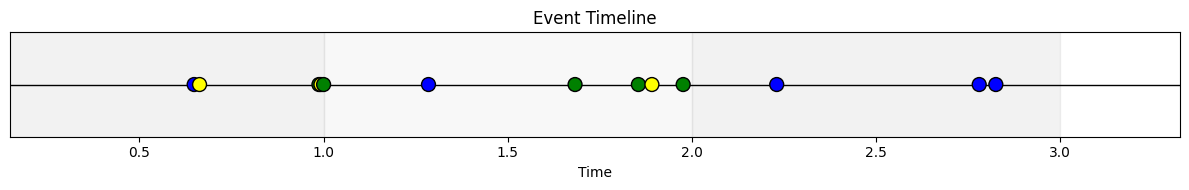

In [8]:
plot_timeline_with_colors(data, intervals)